# 임의 데이터 생성

In [2]:
import pandas as pd

df = pd.read_csv('./data_daejeon.csv', sep='\t', encoding='cp949')

df.head(), df.columns

(   MTDT_INDEX                DTCT_UID  ROAD_POTHOLE  ROAD_CRACK   PLC_LTTD  \
 0        2603  RAD01_240119162357_441             1           0  36.384627   
 1        2613    RAD01_240119162610_0             1           0  36.398713   
 2        2614    RAD01_240119162611_0             1           0  36.398783   
 3        2655    RAD01_240119163618_0             1           0  36.427899   
 4        2659  RAD01_240119163629_608             1           0  36.427741   
 
      PLC_LGTD              ROAD_INFO DSTA_LGLD_INFO DSTA_ADSTRD_INFO  IMG_CONF  
 0  127.343459  대전광역시 유성구 신성동 산 26-12            신성동              신성동       NaN  
 1  127.357864    대전광역시 유성구 장동 202-11             장동              신성동       NaN  
 2  127.358005    대전광역시 유성구 장동 202-11             장동              신성동       NaN  
 3  127.387323     대전광역시 유성구 관평동 1286            관평동              관평동       NaN  
 4  127.387724     대전광역시 유성구 관평동 1286            관평동              관평동       NaN  ,
 Index(['MTDT_INDEX', 'DTCT_UID

In [3]:
import numpy as np
import pandas as pd

# -----------------------------
# 0. 기존 컬럼 확인
# -----------------------------
print("=== 기존 컬럼 목록 ===")
print(df.columns)

# 1. 현실성 반영 랜덤값 생성

n = len(df)

# 포트홀 점수 랜덤 생성 (0~4)
df['ROAD_POTHOLE'] = np.random.choice(
    [0, 1, 2, 3, 4],
    size=n,
    p=[0.60, 0.25, 0.10, 0.04, 0.01]
)

# 균열 점수 랜덤 생성 (0~4)
df['ROAD_CRACK'] = np.random.choice(
    [0, 1, 2, 3, 4],
    size=n,
    p=[0.40, 0.40, 0.15, 0.04, 0.01]
)

print("\n=== 랜덤값 생성 완료 ===")
print(df[['ROAD_POTHOLE', 'ROAD_CRACK']].head())

# 2. 도로 상태 점수 계산
df['damage_score'] = (
    df['ROAD_POTHOLE'] * 0.6 +
    df['ROAD_CRACK'] * 0.4
)

# 3. 도로 상태 등급 정의
df['road_grade'] = pd.cut(
    df['damage_score'],
    bins=[-1, 1.0, 2.5, np.inf],
    labels=[0, 1, 2]  # 0=좋음, 1=보통, 2=나쁨
).astype(int)


# 4. 불균형 분포 출력
print("\n=== 도로 등급 분포(개수) ===")
print(df['road_grade'].value_counts().sort_index())

print("\n=== 도로 등급 분포(비율) ===")
print(df['road_grade'].value_counts(normalize=True).sort_index())

=== 기존 컬럼 목록 ===
Index(['MTDT_INDEX', 'DTCT_UID', 'ROAD_POTHOLE', 'ROAD_CRACK', 'PLC_LTTD',
       'PLC_LGTD', 'ROAD_INFO', 'DSTA_LGLD_INFO', 'DSTA_ADSTRD_INFO',
       'IMG_CONF'],
      dtype='object')

=== 랜덤값 생성 완료 ===
   ROAD_POTHOLE  ROAD_CRACK
0             2           0
1             0           1
2             0           1
3             0           1
4             4           0

=== 도로 등급 분포(개수) ===
road_grade
0    1148
1     324
2      22
Name: count, dtype: int64

=== 도로 등급 분포(비율) ===
road_grade
0    0.768407
1    0.216867
2    0.014726
Name: proportion, dtype: float64


In [4]:
import numpy as np
import pandas as pd

n = len(df)

# ----------------------------------------------
# 1) DTCT_UID에서 DATE 추출
# ----------------------------------------------
def extract_date(uid):
    try:
        middle = uid.split("_")[1]
        yymmdd = middle[:6]  # 앞 6자리
        return "20" + yymmdd  # YYMMDD → 20YYMMDD 형식 가정
    except:
        return np.nan

df["DATE_STR"] = df["DTCT_UID"].astype(str).apply(extract_date)
df["DATE"] = pd.to_datetime(df["DATE_STR"], format="%Y%m%d", errors="coerce")

print(df[["DTCT_UID", "DATE"]].head())


# ----------------------------------------------
# 2) 교통데이터 임의 생성
# ----------------------------------------------
df["speed"] = np.random.uniform(10, 80, n)                     # 차량 평균 속도
df["volume"] = np.random.randint(50, 3000, n)                 # 교통량
df["occupancy"] = np.random.uniform(1, 60, n)                 # 차지율(%)


# ----------------------------------------------
# 3) 기상데이터 임의 생성
# ----------------------------------------------
df["TA_AVG"] = np.random.uniform(-5, 30, n)
df["TA_MAX"] = df["TA_AVG"] + np.random.uniform(2, 10, n)
df["TA_MIN"] = df["TA_AVG"] - np.random.uniform(2, 10, n)

df["RN_DAY"] = np.random.exponential(scale=10, size=n).clip(0, 120)
df["RN_DUR"] = np.random.uniform(0, 12, n)
df["RN_D99"] = np.random.uniform(0, 40, n)

df["SD_DAY"] = np.random.exponential(scale=3, size=n).clip(0, 20)
df["SD_NEW"] = np.random.uniform(0, 10, n)
df["SD_MAX"] = np.random.uniform(0, 30, n)

df["HM_AVG"] = np.random.uniform(20, 100, n)
df["SI_DAY"] = np.random.uniform(0, 25, n)
df["SS_DAY"] = np.random.uniform(0, 12, n)


# ----------------------------------------------
# 4) 생성된 컬럼 확인
# ----------------------------------------------
cols = [
    "DTCT_UID", "DATE",
    "speed", "volume", "occupancy",
    "TA_AVG", "TA_MAX", "TA_MIN",
    "RN_DAY", "RN_DUR", "RN_D99",
    "SD_DAY", "SD_NEW", "SD_MAX",
    "HM_AVG", "SI_DAY", "SS_DAY"
]

print("\n=== 생성된 교통 + 기상 + DATE 컬럼 미리보기 ===")
print(df[cols].head())

                 DTCT_UID       DATE
0  RAD01_240119162357_441 2024-01-19
1    RAD01_240119162610_0 2024-01-19
2    RAD01_240119162611_0 2024-01-19
3    RAD01_240119163618_0 2024-01-19
4  RAD01_240119163629_608 2024-01-19

=== 생성된 교통 + 기상 + DATE 컬럼 미리보기 ===
                 DTCT_UID       DATE      speed  volume  occupancy     TA_AVG  \
0  RAD01_240119162357_441 2024-01-19  15.691481    1731  33.617134  25.070765   
1    RAD01_240119162610_0 2024-01-19  26.856247     375  11.582654  12.090200   
2    RAD01_240119162611_0 2024-01-19  15.948071     665  57.961806  -4.479897   
3    RAD01_240119163618_0 2024-01-19  31.144027    2662  22.339361  20.767619   
4  RAD01_240119163629_608 2024-01-19  29.068852    2908  22.613110  27.902352   

      TA_MAX     TA_MIN     RN_DAY     RN_DUR     RN_D99     SD_DAY    SD_NEW  \
0  32.961628  17.205634   2.452842   4.007682  28.064805   1.672078  0.105323   
1  18.295156   8.901527   8.849080   3.110572  37.450040   1.164760  4.214086   
2   0.049060

In [5]:
import numpy as np
import pandas as pd

# ----------------------------------------------
# 1) 날짜 기반 계절 판별 함수
# ----------------------------------------------
def get_season(month):
    # 1~12 -> 1=Winter, 2=Spring, 3=Summer, 4=Fall
    if month in [12, 1, 2]:
        return 1   # Winter
    elif month in [3, 4, 5]:
        return 2   # Spring
    elif month in [6, 7, 8]:
        return 3   # Summer
    else:
        return 4   # Fall


# ----------------------------------------------
# 2) 월별 평균 기온 베이스값 (현실 기반)
# ----------------------------------------------
monthly_temp_base = {
    1: -2,   2: 0,    3: 5,
    4: 12,  5: 17,   6: 22,
    7: 26,  8: 27,   9: 22,
    10: 15, 11: 8,  12: 2
}


# ----------------------------------------------
# 3) 날짜 기반 realistic synthetic weather 생성
# ----------------------------------------------
def generate_weather(df):

    n = len(df)

    # 월 추출
    months = df["DATE"].dt.month.values

    # 3-1) 온도 생성
    TA_AVG = np.array([monthly_temp_base[m] for m in months]) \
             + np.random.normal(0, 3, n)

    TA_MAX = TA_AVG + np.random.uniform(2, 8, n)
    TA_MIN = TA_AVG - np.random.uniform(2, 8, n)

    # 3-2) 강수량 (월별 강수확률 적용)
    rain_prob_by_month = {
        1: 0.10, 2: 0.12, 3: 0.20,
        4: 0.30, 5: 0.35, 6: 0.45,
        7: 0.55, 8: 0.50, 9: 0.40,
        10: 0.30, 11: 0.20, 12: 0.15
    }

    rain_flags = np.array([
        np.random.rand() < rain_prob_by_month[m]
        for m in months
    ])

    RN_DAY = np.where(
        rain_flags,
        np.random.exponential(scale=15, size=n).clip(0, 120),
        0
    )

    RN_DUR = np.where(
        RN_DAY > 0,
        np.random.uniform(1, 8, n),
        0
    )

    RN_D99 = np.where(
        RN_DAY > 0,
        np.random.uniform(5, 40, n),
        0
    )

    # 3-3) 적설량 (겨울만 발생)
    snow_flags = np.array([(m in [12, 1, 2]) for m in months])
    SD_DAY = np.where(
        snow_flags,
        np.random.exponential(scale=3, size=n).clip(0, 25),
        0
    )
    SD_NEW = np.where(
        SD_DAY > 0,
        np.random.uniform(0, 10, n),
        0
    )
    SD_MAX = np.where(
        SD_DAY > 0,
        SD_DAY + np.random.uniform(0, 5, n),
        0
    )

    # 3-4) 습도, 일사량, 일조시간
    HM_AVG = np.random.uniform(40, 95, n)
    SI_DAY = np.random.uniform(5, 25, n)  # 일사량
    SS_DAY = np.random.uniform(3, 12, n)  # 일조시간

    df["TA_AVG"] = TA_AVG
    df["TA_MAX"] = TA_MAX
    df["TA_MIN"] = TA_MIN

    df["RN_DAY"] = RN_DAY
    df["RN_DUR"] = RN_DUR
    df["RN_D99"] = RN_D99

    df["SD_DAY"] = SD_DAY
    df["SD_NEW"] = SD_NEW
    df["SD_MAX"] = SD_MAX

    df["HM_AVG"] = HM_AVG
    df["SI_DAY"] = SI_DAY
    df["SS_DAY"] = SS_DAY

    return df


# ----------------------------------------------
# 4) DATE 기반 파생 Feature 생성
# ----------------------------------------------
def add_date_features(df):

    df["year"] = df["DATE"].dt.year
    df["month"] = df["DATE"].dt.month
    df["day"] = df["DATE"].dt.day

    df["weekofyear"] = df["DATE"].dt.isocalendar().week.astype(int)
    df["dayofweek"] = df["DATE"].dt.dayofweek  # 0=Mon, 6=Sun

    # 1=겨울, 2=봄, 3=여름, 4=가을
    df["season"] = df["month"].apply(get_season)

    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    return df


# ----------------------------------------------
# 5) 전체 실행 (df에 DATE가 존재한다고 가정)
# ----------------------------------------------
df = generate_weather(df)
df = add_date_features(df)

print("\n=== 기상데이터 + 날짜 파생컬럼 생성 완료 ===")
print(df[[
    "DATE", "TA_AVG", "TA_MAX", "TA_MIN", "RN_DAY",
    "SD_DAY", "HM_AVG", "SI_DAY", "SS_DAY",
    "month", "weekofyear", "season", "is_weekend"
]].head())



=== 기상데이터 + 날짜 파생컬럼 생성 완료 ===
        DATE    TA_AVG    TA_MAX     TA_MIN  RN_DAY     SD_DAY     HM_AVG  \
0 2024-01-19 -7.938514 -0.381029 -15.187043     0.0   2.646632  82.831833   
1 2024-01-19  0.256709  6.993134  -4.408011     0.0  10.614789  92.755989   
2 2024-01-19 -5.105319  0.072898 -10.107549     0.0   1.070187  70.468371   
3 2024-01-19 -2.335160 -0.072311  -5.046959     0.0   1.853311  92.805399   
4 2024-01-19  4.755065  7.699799  -0.549019     0.0   6.464264  82.672096   

      SI_DAY     SS_DAY  month  weekofyear  season  is_weekend  
0  14.231695   3.166767      1           3       1           0  
1  19.222560   9.353647      1           3       1           0  
2  22.059306   3.914081      1           3       1           0  
3  19.175007  11.777354      1           3       1           0  
4  18.521652   5.172642      1           3       1           0  


In [6]:
df.columns

Index(['MTDT_INDEX', 'DTCT_UID', 'ROAD_POTHOLE', 'ROAD_CRACK', 'PLC_LTTD',
       'PLC_LGTD', 'ROAD_INFO', 'DSTA_LGLD_INFO', 'DSTA_ADSTRD_INFO',
       'IMG_CONF', 'damage_score', 'road_grade', 'DATE_STR', 'DATE', 'speed',
       'volume', 'occupancy', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR',
       'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY',
       'year', 'month', 'day', 'weekofyear', 'dayofweek', 'season',
       'is_weekend'],
      dtype='object')

In [7]:
import pandas as pd
import numpy as np

# ----------------------------------------------------
# DATE 기준 rolling weather feature 생성 함수
# ----------------------------------------------------
def add_rolling_weather_features(df):

    # 날짜 정렬 후 rolling 계산
    df = df.sort_values("DATE")

    # 일별 온도 차이 (variation)
    df["temp_range"] = df["TA_MAX"] - df["TA_MIN"]

    # 계산할 기간
    windows = [7, 14, 30]

    for w in windows:

        # 1) 강수량 rolling sum
        df[f"rolling_{w}_rain"] = df["RN_DAY"].rolling(window=w, min_periods=1).sum()

        # 2) 평균기온 rolling mean
        df[f"rolling_{w}_temp"] = df["TA_AVG"].rolling(window=w, min_periods=1).mean()

        # 3) 온도 변동성 (일교차 평균)
        df[f"rolling_{w}_temp_range"] = df["temp_range"].rolling(window=w, min_periods=1).mean()

    return df


# ----------------------------------------------------
# 실행 (df 존재한다고 가정)
# ----------------------------------------------------
df = add_rolling_weather_features(df)

print("\n=== Rolling Weather Feature 생성 완료 ===")
print(df[[
    "DATE",
    "RN_DAY", "TA_AVG", "temp_range",
    "rolling_7_rain", "rolling_14_rain", "rolling_30_rain",
    "rolling_7_temp", "rolling_14_temp", "rolling_30_temp",
    "rolling_7_temp_range", "rolling_14_temp_range", "rolling_30_temp_range"
]].head())



=== Rolling Weather Feature 생성 완료 ===
        DATE  RN_DAY    TA_AVG  temp_range  rolling_7_rain  rolling_14_rain  \
0 2024-01-19     0.0 -7.938514   14.806014             0.0              0.0   
1 2024-01-19     0.0  0.256709   11.401145             0.0              0.0   
2 2024-01-19     0.0 -5.105319   10.180447             0.0              0.0   
3 2024-01-19     0.0 -2.335160    4.974648             0.0              0.0   
4 2024-01-19     0.0  4.755065    8.248818             0.0              0.0   

   rolling_30_rain  rolling_7_temp  rolling_14_temp  rolling_30_temp  \
0              0.0       -7.938514        -7.938514        -7.938514   
1              0.0       -3.840903        -3.840903        -3.840903   
2              0.0       -4.262375        -4.262375        -4.262375   
3              0.0       -3.780571        -3.780571        -3.780571   
4              0.0       -2.073444        -2.073444        -2.073444   

   rolling_7_temp_range  rolling_14_temp_range  rolli

# 모델 학습

In [8]:
### ============================================
### [BLOCK 1] Feature 준비 + 전처리 + 분할
### ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def prepare_features(df):

    label = "road_grade"

    numeric_features = [
        "speed", "volume", "occupancy",
        "TA_AVG", "TA_MAX", "TA_MIN",
        "RN_DAY", "RN_DUR", "RN_D99",
        "SD_DAY", "SD_NEW", "SD_MAX",
        "HM_AVG", "SI_DAY", "SS_DAY",
        "rolling_7_rain", "rolling_14_rain", "rolling_30_rain",
        "rolling_7_temp", "rolling_14_temp", "rolling_30_temp",
        "rolling_7_temp_range", "rolling_14_temp_range", "rolling_30_temp_range"
    ]
    numeric_features = [c for c in numeric_features if c in df.columns]

    categorical_features = ["season", "is_weekend", "width_category"]
    categorical_features = [c for c in categorical_features if c in df.columns]

    df = df.dropna(subset=[label])
    y = df[label].astype(int)

    X = df[numeric_features + categorical_features].copy()

    # categorical → string
    for col in categorical_features:
        X[col] = X[col].astype(str)

    return X, y, numeric_features, categorical_features


def split_dataset(X, y):
    X_train_temp, X_test, y_train_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_temp, y_train_temp, test_size=0.25, random_state=42, stratify=y_train_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_and_transform(num_cols, cat_cols, X_train, X_val, X_test):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    X_train_t = preprocessor.fit_transform(X_train)
    X_val_t = preprocessor.transform(X_val)
    X_test_t = preprocessor.transform(X_test)

    return preprocessor, X_train_t, X_val_t, X_test_t


# 실행 (df는 이미 있음)
X, y, num_cols, cat_cols = prepare_features(df)
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
preprocessor, X_train_t, X_val_t, X_test_t = build_and_transform(
    num_cols, cat_cols, X_train, X_val, X_test
)

[0]	validation_0-mlogloss:0.83779
[50]	validation_0-mlogloss:0.64304
[100]	validation_0-mlogloss:0.60803
[150]	validation_0-mlogloss:0.60535
[200]	validation_0-mlogloss:0.61456
[250]	validation_0-mlogloss:0.62624
[300]	validation_0-mlogloss:0.64110
[350]	validation_0-mlogloss:0.65770
[400]	validation_0-mlogloss:0.67018
[450]	validation_0-mlogloss:0.68324
[500]	validation_0-mlogloss:0.69876
[550]	validation_0-mlogloss:0.71091
[599]	validation_0-mlogloss:0.72223

===== XGBoost Validation =====
              precision    recall  f1-score   support

           0       0.78      0.98      0.87       230
           1       0.44      0.06      0.11        65
           2       0.00      0.00      0.00         4

    accuracy                           0.77       299
   macro avg       0.41      0.35      0.32       299
weighted avg       0.69      0.77      0.69       299



c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


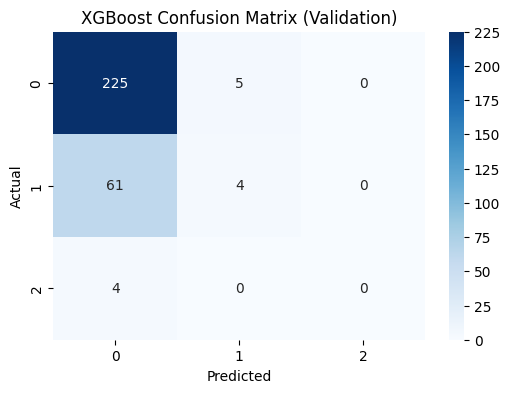


===== XGBoost Test =====
              precision    recall  f1-score   support

           0       0.77      0.98      0.86       230
           1       0.00      0.00      0.00        65
           2       0.00      0.00      0.00         4

    accuracy                           0.76       299
   macro avg       0.26      0.33      0.29       299
weighted avg       0.59      0.76      0.66       299



c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


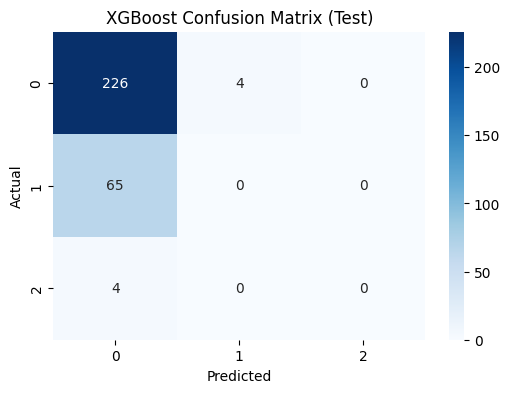

In [9]:
### ============================================
### [BLOCK 2] XGBoost 학습 + 혼동행렬 시각화
### ============================================

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def build_xgb_model():
    return XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        learning_rate=0.03,
        n_estimators=600,
        max_depth=7,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        gamma=0.05,
        tree_method="hist",
        random_state=42
    )

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1,2], yticklabels=[0,1,2])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ----- 모델 학습 -----
xgb_model = build_xgb_model()

xgb_model.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=50
)

# ----- Validation 평가 -----
print("\n===== XGBoost Validation =====")
pred_val = xgb_model.predict(X_val_t)
print(classification_report(y_val, pred_val))

cm_val = confusion_matrix(y_val, pred_val)
plot_confusion_matrix(cm_val, "XGBoost Confusion Matrix (Validation)")

# ----- Test 평가 -----
print("\n===== XGBoost Test =====")
pred_test = xgb_model.predict(X_test_t)
print(classification_report(y_test, pred_test))

cm_test = confusion_matrix(y_test, pred_test)
plot_confusion_matrix(cm_test, "XGBoost Confusion Matrix (Test)")

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\hyebi\anaconda3\envs\EDA\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\hyebi\anaconda3\envs\EDA\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\hyebi\anaconda3\envs\EDA\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\hyebi\anaconda3\envs\EDA\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5127
[LightGBM] [Info] Number of data points in the train set: 896, number of used features: 30
[LightGBM] [Info] Start training from score -0.264152
[LightGBM] [Info] Start training from score -1.530082
[LightGBM] [Info] Start training from score -4.158883
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 30 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is il

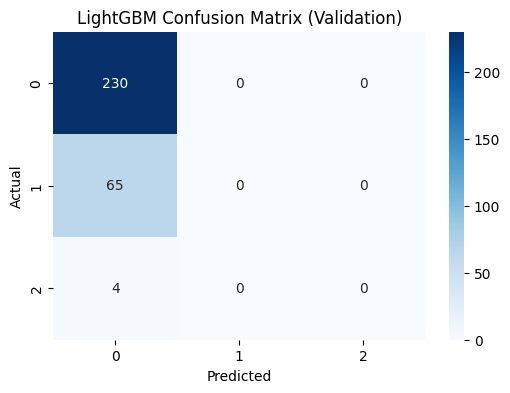

c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is il


===== LightGBM Test =====
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       230
           1       0.00      0.00      0.00        65
           2       0.00      0.00      0.00         4

    accuracy                           0.77       299
   macro avg       0.26      0.33      0.29       299
weighted avg       0.59      0.77      0.67       299



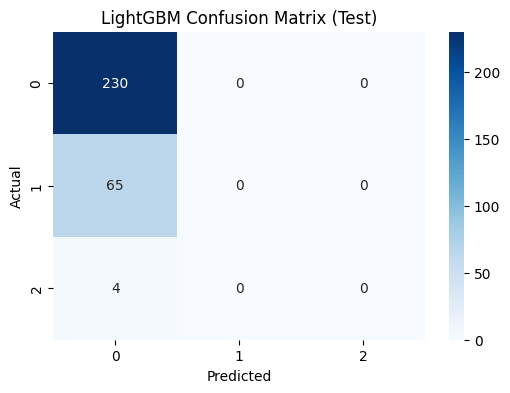

In [10]:
### ============================================
### [BLOCK 3] LightGBM 학습 + 혼동행렬 시각화
### ============================================

import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def build_lgbm_model():
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=3,
        learning_rate=0.03,
        n_estimators=400,
        subsample=0.85,
        colsample_bytree=0.85,
        num_leaves=63,
        random_state=42
    )

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1,2], yticklabels=[0,1,2])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ----- 모델 학습 -----
lgbm_model = build_lgbm_model()

lgbm_model.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=20)
    ]
)

# ----- Validation 평가 -----
print("\n===== LightGBM Validation =====")
pred_val = lgbm_model.predict(X_val_t)
print(classification_report(y_val, pred_val))

cm_val = confusion_matrix(y_val, pred_val)
plot_confusion_matrix(cm_val, "LightGBM Confusion Matrix (Validation)")

# ----- Test 평가 -----
print("\n===== LightGBM Test =====")
pred_test = lgbm_model.predict(X_test_t)
print(classification_report(y_test, pred_test))

cm_test = confusion_matrix(y_test, pred_test)
plot_confusion_matrix(cm_test, "LightGBM Confusion Matrix (Test)")

# 7월 연구노트

=== 원본 클래스 분포 ===
road_grade
0    1148
1     324
2      22
Name: count, dtype: int64
road_grade
0    0.768407
1    0.216867
2    0.014726
Name: proportion, dtype: float64


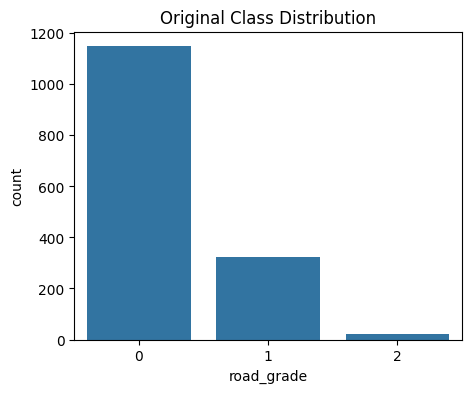

In [11]:
### BLOCK 2 — df 기반 클래스 불균형 분석 + 샘플링 적용

print("=== 원본 클래스 분포 ===")
print(df['road_grade'].value_counts().sort_index())
print(df['road_grade'].value_counts(normalize=True).sort_index())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="road_grade")
plt.title("Original Class Distribution")
plt.show()

=== Negative Sampling 후 분포 ===
road_grade
0    574
1    324
2     22
Name: count, dtype: int64


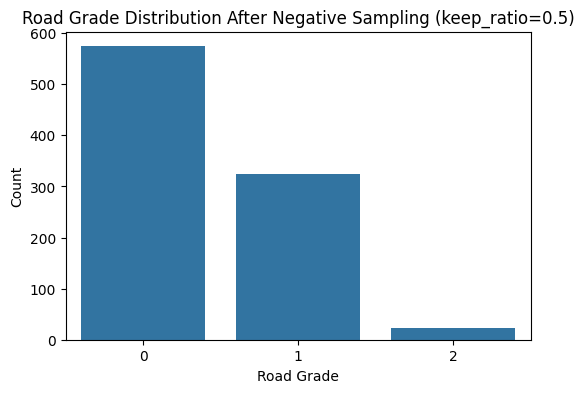

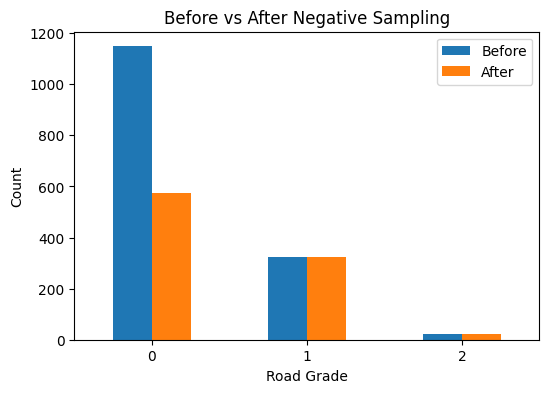

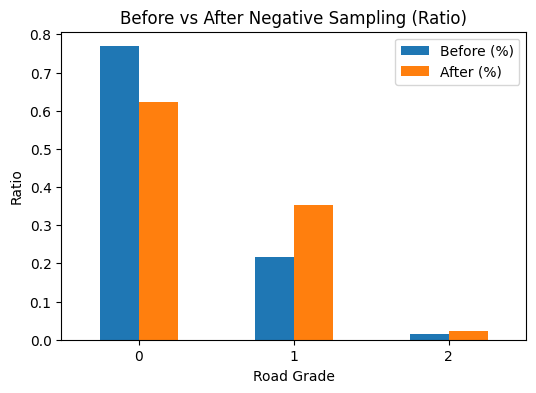

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Negative Sampling 함수 동일
# ============================
def negative_sampling_df(df, keep_ratio=0.5):
    df_major = df[df['road_grade'] == 0]
    df_minor = df[df['road_grade'] != 0]

    df_major_down = df_major.sample(frac=keep_ratio, random_state=42)
    df_new = pd.concat([df_major_down, df_minor], axis=0).sample(frac=1, random_state=42)

    return df_new


# ============================
# Negative Sampling 실행
# ============================
df_neg50 = negative_sampling_df(df, keep_ratio=0.5)

print("=== Negative Sampling 후 분포 ===")
print(df_neg50['road_grade'].value_counts().sort_index())


# ============================
# 1) Negative Sampling 후 분포 그래프
# ============================
plt.figure(figsize=(6,4))
sns.countplot(data=df_neg50, x="road_grade")
plt.title("Road Grade Distribution After Negative Sampling (keep_ratio=0.5)")
plt.xlabel("Road Grade")
plt.ylabel("Count")
plt.show()


# ============================
# 2) Before vs After 분포 비교 (막대 그래프)
# ============================
before = df['road_grade'].value_counts().sort_index()
after = df_neg50['road_grade'].value_counts().sort_index()

compare_df = pd.DataFrame({
    'Before': before,
    'After': after
})

compare_df.plot(kind='bar', figsize=(6,4))
plt.title("Before vs After Negative Sampling")
plt.xlabel("Road Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# ============================
# 3) Before vs After 비율 비교 (Stacked Bar)
# ============================
ratio_before = df['road_grade'].value_counts(normalize=True).sort_index()
ratio_after = df_neg50['road_grade'].value_counts(normalize=True).sort_index()

ratio_df = pd.DataFrame({
    'Before (%)': ratio_before,
    'After (%)': ratio_after
})

ratio_df.plot(kind='bar', figsize=(6,4))
plt.title("Before vs After Negative Sampling (Ratio)")
plt.xlabel("Road Grade")
plt.ylabel("Ratio")
plt.xticks(rotation=0)
plt.show()


===== Undersampling 10% =====
road_grade
0    115
1    324
2     22
Name: count, dtype: int64

===== Undersampling 20% =====
road_grade
0    230
1    324
2     22
Name: count, dtype: int64

===== Undersampling 30% =====
road_grade
0    344
1    324
2     22
Name: count, dtype: int64

===== Undersampling 40% =====
road_grade
0    459
1    324
2     22
Name: count, dtype: int64

===== Undersampling 50% =====
road_grade
0    574
1    324
2     22
Name: count, dtype: int64


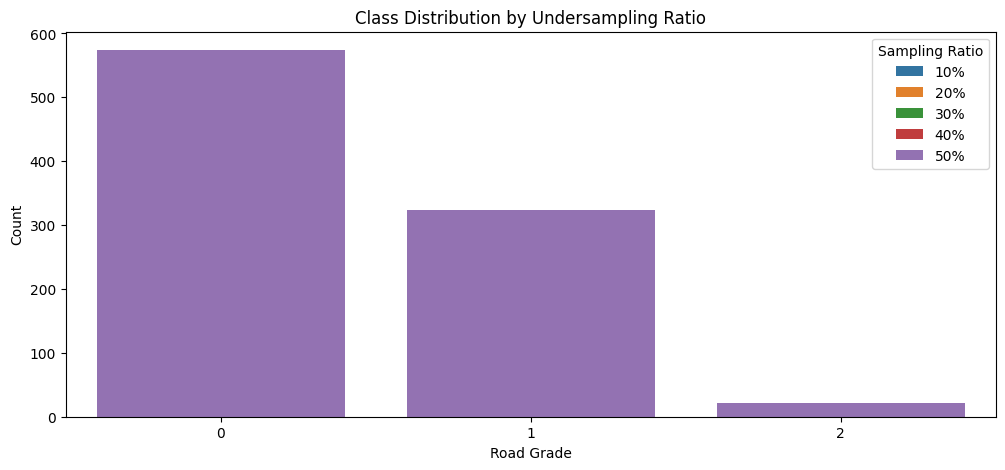

<Figure size 1000x600 with 0 Axes>

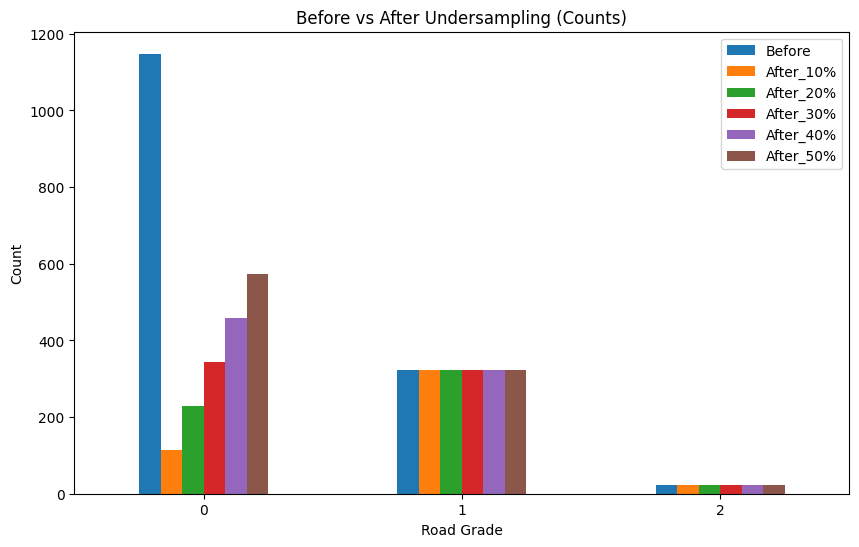

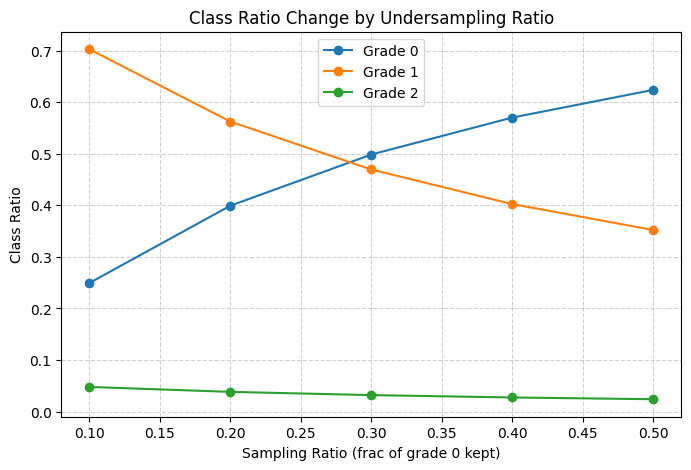

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------
# 1) 언더샘플링 함수 (비율별)
# ----------------------------------------
def undersample(df, ratio):
    df_major = df[df['road_grade'] == 0]
    df_minor = df[df['road_grade'] != 0]

    df_major_down = df_major.sample(frac=ratio, random_state=42)
    df_new = pd.concat([df_major_down, df_minor], axis=0).sample(frac=1, random_state=42)

    return df_new


# ----------------------------------------
# 2) 실험 비율
# ----------------------------------------
ratios = [0.1, 0.2, 0.3, 0.4, 0.5]

results = {}
ratio_summary = []

# ----------------------------------------
# 3) 비율별 Undersampling 실행 + 저장
# ----------------------------------------
for r in ratios:
    df_r = undersample(df, ratio=r)
    results[r] = df_r

    grade_counts = df_r["road_grade"].value_counts().sort_index()
    grade_ratio = df_r["road_grade"].value_counts(normalize=True).sort_index()

    ratio_summary.append({
        "ratio": r,
        "grade_0_ratio": grade_ratio.get(0, 0),
        "grade_1_ratio": grade_ratio.get(1, 0),
        "grade_2_ratio": grade_ratio.get(2, 0)
    })

    print(f"\n===== Undersampling {int(r*100)}% =====")
    print(grade_counts)


ratio_df = pd.DataFrame(ratio_summary)


# ==================================================
# (A) 비율별 Undersampling 분포 시각화
# ==================================================
plt.figure(figsize=(12,5))
for r in ratios:
    sns.countplot(data=results[r], x="road_grade", label=f"{int(r*100)}%")
plt.title("Class Distribution by Undersampling Ratio")
plt.xlabel("Road Grade")
plt.ylabel("Count")
plt.legend(title="Sampling Ratio")
plt.show()


# ==================================================
# (B) Before vs After 비교 그래프
# ==================================================
before = df["road_grade"].value_counts().sort_index()

plt.figure(figsize=(10,6))
compare = pd.DataFrame({"Before": before})

for r in ratios:
    compare[f"After_{int(r*100)}%"] = results[r]["road_grade"].value_counts().sort_index()

compare.plot(kind="bar", figsize=(10,6))
plt.title("Before vs After Undersampling (Counts)")
plt.xlabel("Road Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# ==================================================
# (C) 비율별 클래스 비중 변화 (특히 등급 0 감소 확인)
# ==================================================
plt.figure(figsize=(8,5))
plt.plot(ratio_df["ratio"], ratio_df["grade_0_ratio"], marker="o", label="Grade 0")
plt.plot(ratio_df["ratio"], ratio_df["grade_1_ratio"], marker="o", label="Grade 1")
plt.plot(ratio_df["ratio"], ratio_df["grade_2_ratio"], marker="o", label="Grade 2")
plt.title("Class Ratio Change by Undersampling Ratio")
plt.xlabel("Sampling Ratio (frac of grade 0 kept)")
plt.ylabel("Class Ratio")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

남은 컬럼: ['MTDT_INDEX', 'ROAD_POTHOLE', 'ROAD_CRACK', 'PLC_LTTD', 'PLC_LGTD', 'IMG_CONF', 'damage_score', 'road_grade', 'speed', 'volume', 'occupancy', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY', 'year', 'month', 'day', 'weekofyear', 'dayofweek', 'season', 'is_weekend', 'temp_range', 'rolling_7_rain', 'rolling_7_temp', 'rolling_7_temp_range', 'rolling_14_rain', 'rolling_14_temp', 'rolling_14_temp_range', 'rolling_30_rain', 'rolling_30_temp', 'rolling_30_temp_range']

=== 원본 road_grade 분포 ===
road_grade
0    1148
1     324
2      22
Name: count, dtype: int64

===== [Baseline] 모델 학습 =====

[Baseline] Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       230
           1       1.00      1.00      1.00        65
           2       1.00      1.00      1.00         4

    accuracy                           1.00       299
   macro avg       1.00   

c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hyebi\anaconda3\envs\EDA\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


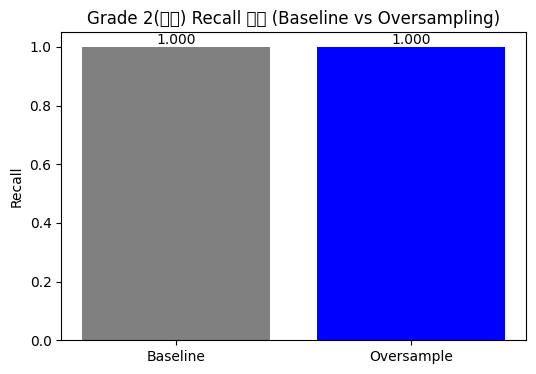

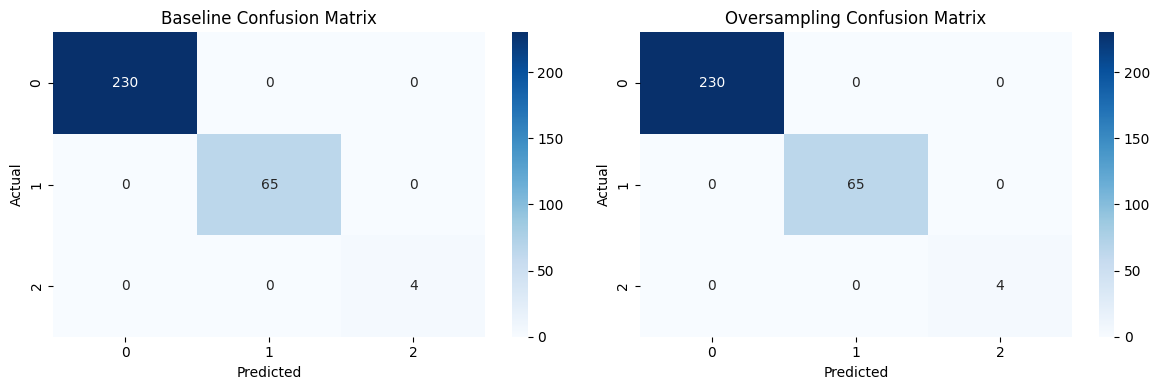

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils import resample
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------
# 0) object / datetime 컬럼 제거 (XGBoost가 싫어함)
# ----------------------------------------------------
non_num_cols = df.select_dtypes(include=["object", "datetime64[ns]"]).columns.tolist()

df_clean = df.drop(columns=non_num_cols).copy()

print("남은 컬럼:", df_clean.columns.tolist())
print("\n=== 원본 road_grade 분포 ===")
print(df_clean["road_grade"].value_counts().sort_index())

# ----------------------------------------------------
# 1) Baseline: 아무 샘플링 없는 모델
# ----------------------------------------------------
X = df_clean.drop(columns=["road_grade"])
y = df_clean["road_grade"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def build_xgb():
    return XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        tree_method="hist",
        random_state=42
    )

print("\n===== [Baseline] 모델 학습 =====")
xgb_base = build_xgb()
xgb_base.fit(X_train, y_train)

pred_base = xgb_base.predict(X_test)
print("\n[Baseline] Classification Report")
print(classification_report(y_test, pred_base))

base_pr, base_rc, base_f1, _ = precision_recall_fscore_support(
    y_test, pred_base, labels=[2]
)
baseline_recall_2 = base_rc[0]
print(f"[Baseline] Grade 2 Recall: {baseline_recall_2:.4f}")

cm_base = confusion_matrix(y_test, pred_base, labels=[0,1,2])


# ----------------------------------------------------
# 2) Train에서 Grade 2 Oversampling
#    → 등급 2를 강하게 늘려서 Recall 끌어올리기
# ----------------------------------------------------
train_df = X_train.copy()
train_df["road_grade"] = y_train.values

df_2 = train_df[train_df["road_grade"] == 2]          # minority
df_not2 = train_df[train_df["road_grade"] != 2]       # 나머지

print("\nTrain Grade 분포(원본):")
print(train_df["road_grade"].value_counts().sort_index())

# 등급2를 나머지 샘플 수와 비슷하게 맞추는 정도로 Oversampling
target_n_2 = len(df_not2)   # 혹은 len(df_not2) * 0.7 정도로 조금 약하게
df_2_over = resample(
    df_2,
    replace=True,
    n_samples=target_n_2,
    random_state=42
)

train_os = pd.concat([df_not2, df_2_over], axis=0).sample(frac=1, random_state=42)
X_train_os = train_os.drop(columns=["road_grade"])
y_train_os = train_os["road_grade"].astype(int)

print("\nTrain Grade 분포(Oversampling 후):")
print(y_train_os.value_counts().sort_index())

# ----------------------------------------------------
# 3) Oversampling 버전 모델 학습
# ----------------------------------------------------
print("\n===== [Oversampling] 모델 학습 =====")
xgb_over = build_xgb()
xgb_over.fit(X_train_os, y_train_os)

pred_over = xgb_over.predict(X_test)  # Test 는 동일 분포 유지
print("\n[Oversampling] Classification Report")
print(classification_report(y_test, pred_over))

ov_pr, ov_rc, ov_f1, _ = precision_recall_fscore_support(
    y_test, pred_over, labels=[2]
)
over_recall_2 = ov_rc[0]
print(f"[Oversampling] Grade 2 Recall: {over_recall_2:.4f}")

cm_over = confusion_matrix(y_test, pred_over, labels=[0,1,2])


# ----------------------------------------------------
# 4) Grade 2 Recall 전/후 비교 시각화
# ----------------------------------------------------
plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Oversample"], [baseline_recall_2, over_recall_2],
        color=["gray", "blue"])
plt.title("Grade 2(나쁨) Recall 변화 (Baseline vs Oversampling)")
plt.ylabel("Recall")
for i, v in enumerate([baseline_recall_2, over_recall_2]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.ylim(0, 1.05)
plt.show()


# ----------------------------------------------------
# 5) Confusion Matrix 비교 시각화 (원본 vs Oversampling)
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2], yticklabels=[0,1,2], ax=axes[0])
axes[0].set_title("Baseline Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_over, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2], yticklabels=[0,1,2], ax=axes[1])
axes[1].set_title("Oversampling Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [15]:
def remove_outliers_z(df, cols, threshold=3):
    df_clean = df.copy()
    for c in cols:
        z = (df_clean[c] - df_clean[c].mean()) / df_clean[c].std()
        df_clean = df_clean[z.abs() <= threshold]
    return df_clean

numeric_for_outlier = [c for c in df.columns if df[c].dtype != 'object' and c not in ['road_grade']]

df_z_clean = remove_outliers_z(df, numeric_for_outlier)
print("Z-score 제거 후 크기:", len(df_z_clean))

Z-score 제거 후 크기: 672


In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

sample_cols = ["speed", "volume", "TA_AVG"]
df_scale = df[sample_cols].copy()

for name, scaler in {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler()
}.items():

    scaled = scaler.fit_transform(df_scale)
    df_scaled = pd.DataFrame(scaled, columns=sample_cols)

    print(f"\n[{name}] scaled summary")
    print(df_scaled.describe())


[standard] scaled summary
             speed        volume        TA_AVG
count  1494.000000  1.494000e+03  1.494000e+03
mean      0.000000 -1.093874e-16 -5.707171e-17
std       1.000335  1.000335e+00  1.000335e+00
min      -1.684944 -1.684431e+00 -2.206037e+00
25%      -0.862595 -8.967929e-01 -6.790520e-01
50%       0.010016 -1.703641e-02 -2.169573e-01
75%       0.845112  8.705414e-01  3.898724e-01
max       1.741338  1.729151e+00  3.464115e+00

[minmax] scaled summary
             speed       volume       TA_AVG
count  1494.000000  1494.000000  1494.000000
mean      0.491770     0.493450     0.389061
std       0.291959     0.293045     0.176421
min       0.000000     0.000000     0.000000
25%       0.240012     0.230737     0.269302
50%       0.494694     0.488459     0.350798
75%       0.738426     0.748473     0.457820
max       1.000000     1.000000     1.000000

[robust] scaled summary
              speed       volume       TA_AVG
count  1.494000e+03  1494.000000  1494.000000
mea

Columns: ['MTDT_INDEX', 'DTCT_UID', 'ROAD_POTHOLE', 'ROAD_CRACK', 'PLC_LTTD', 'PLC_LGTD', 'ROAD_INFO', 'DSTA_LGLD_INFO', 'DSTA_ADSTRD_INFO', 'IMG_CONF', 'damage_score', 'road_grade', 'DATE_STR', 'DATE', 'speed', 'volume', 'occupancy', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY', 'year', 'month', 'day', 'weekofyear', 'dayofweek', 'season', 'is_weekend', 'temp_range', 'rolling_7_rain', 'rolling_7_temp', 'rolling_7_temp_range', 'rolling_14_rain', 'rolling_14_temp', 'rolling_14_temp_range', 'rolling_30_rain', 'rolling_30_temp', 'rolling_30_temp_range']
block_id가 없어 임의 생성합니다.

=== Rolling Damage Columns 생성 완료 ===
   rolling_7_damage  rolling_30_damage  rolling_90_damage
0               1.0                1.0                1.0
1               2.0                2.0                2.0
2               3.0                3.0                3.0
3               4.0                4.0                4.0
4               5.0

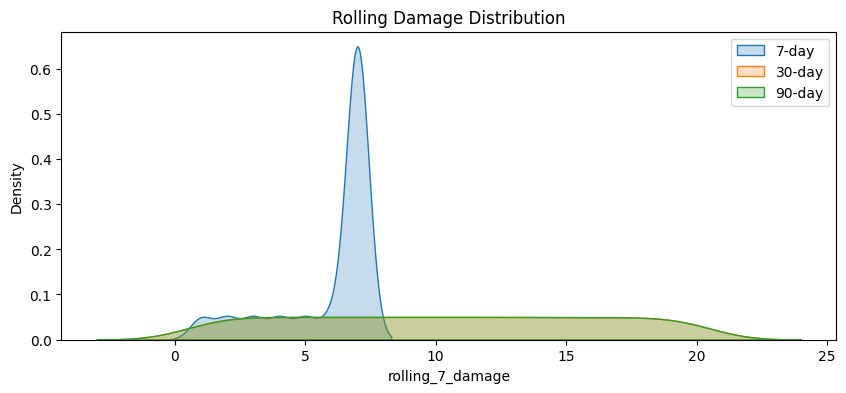

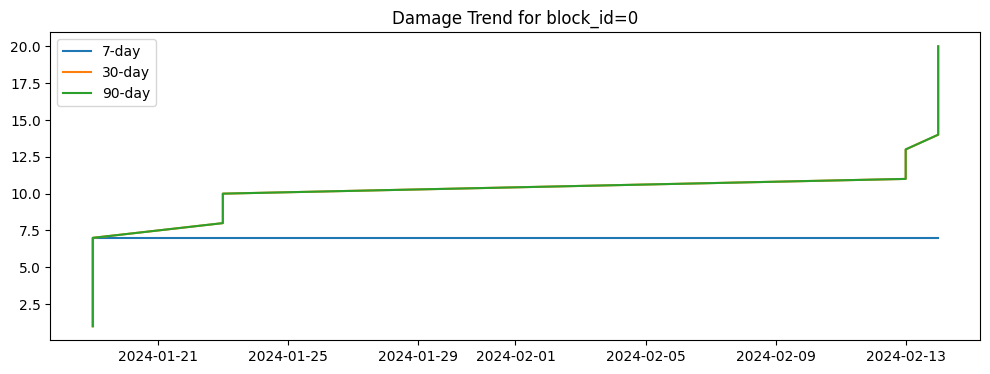

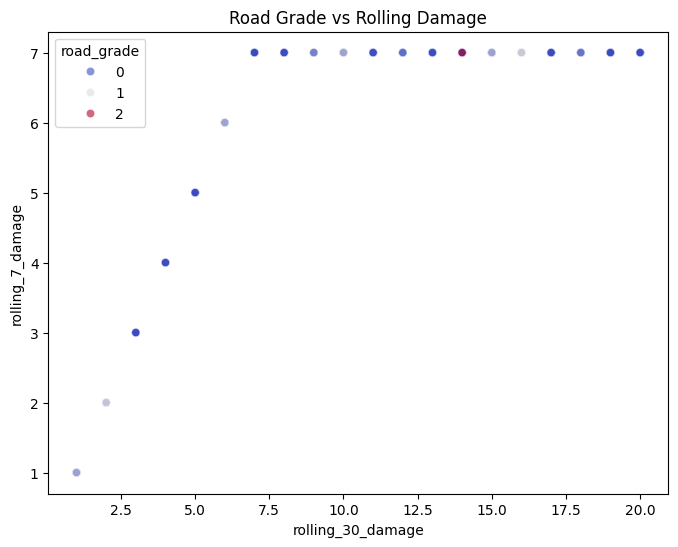

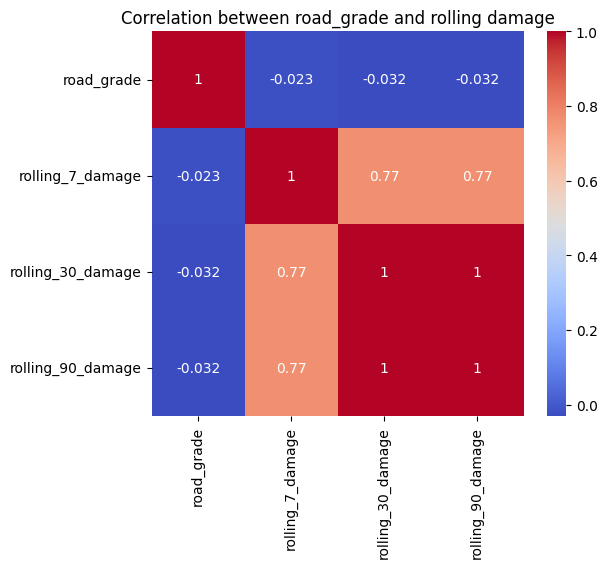

In [17]:
### ============================================
### BLOCK — Rolling Damage Calculation + Visualization
### ============================================

# 1) block_id 존재 여부 확인
print("Columns:", df.columns.tolist())

if "block_id" not in df.columns:
    print("block_id가 없어 임의 생성합니다.")
    df["block_id"] = (df.index // 20).astype(int)

# 2) 날짜 정렬
df = df.sort_values("DATE")

# 3) Rolling Damage 생성
df["rolling_7_damage"] = df.groupby("block_id")["road_grade"].transform(
    lambda x: x.rolling(7, min_periods=1).count()
)
df["rolling_30_damage"] = df.groupby("block_id")["road_grade"].transform(
    lambda x: x.rolling(30, min_periods=1).count()
)
df["rolling_90_damage"] = df.groupby("block_id")["road_grade"].transform(
    lambda x: x.rolling(90, min_periods=1).count()
)

print("\n=== Rolling Damage Columns 생성 완료 ===")
print(df[["rolling_7_damage","rolling_30_damage","rolling_90_damage"]].head())


import matplotlib.pyplot as plt
import seaborn as sns

# 4) 시각화 1: rolling_7 / 30 / 90 damage 분포
plt.figure(figsize=(10,4))
sns.kdeplot(df["rolling_7_damage"], label="7-day", fill=True)
sns.kdeplot(df["rolling_30_damage"], label="30-day", fill=True)
sns.kdeplot(df["rolling_90_damage"], label="90-day", fill=True)
plt.legend()
plt.title("Rolling Damage Distribution")
plt.show()

# 5) 시각화 2: 특정 block의 damage trend
sample_block = df["block_id"].iloc[0]
df_sample_block = df[df["block_id"] == sample_block]

plt.figure(figsize=(12,4))
plt.plot(df_sample_block["DATE"], df_sample_block["rolling_7_damage"], label="7-day")
plt.plot(df_sample_block["DATE"], df_sample_block["rolling_30_damage"], label="30-day")
plt.plot(df_sample_block["DATE"], df_sample_block["rolling_90_damage"], label="90-day")
plt.title(f"Damage Trend for block_id={sample_block}")
plt.legend()
plt.show()

# 6) 시각화 3: road_grade vs rolling damage (heatmap-like)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="rolling_30_damage",
    y="rolling_7_damage",
    hue="road_grade",
    alpha=0.6,
    palette="coolwarm"
)
plt.title("Road Grade vs Rolling Damage")
plt.show()

# 7) 시각화 4: 전체 Heatmap (상관 관계)
damage_corr_cols = ["road_grade","rolling_7_damage","rolling_30_damage","rolling_90_damage"]

plt.figure(figsize=(6,5))
sns.heatmap(df[damage_corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between road_grade and rolling damage")
plt.show()

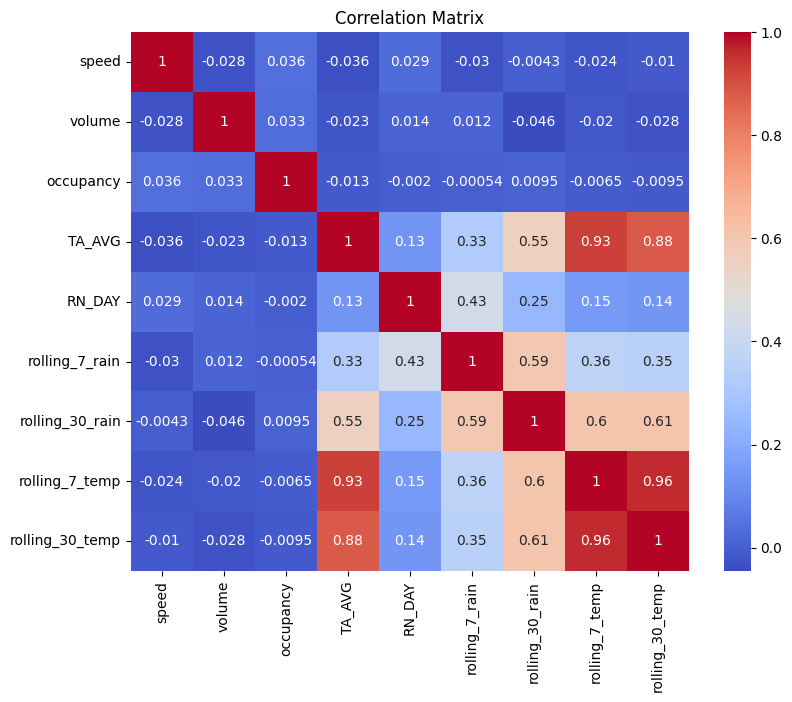

In [18]:
corr_features = [
    "speed", "volume", "occupancy",
    "TA_AVG", "RN_DAY",
    "rolling_7_rain", "rolling_30_rain",
    "rolling_7_temp", "rolling_30_temp",
]

corr_features = [c for c in corr_features if c in df.columns]

plt.figure(figsize=(9,7))
sns.heatmap(df[corr_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df[corr_features].dropna()

vif_data = pd.DataFrame({
    "feature": corr_features,
    "VIF": [variance_inflation_factor(df_vif.values, i) 
            for i in range(df_vif.shape[1])]
})

print(vif_data.sort_values("VIF", ascending=False))

           feature        VIF
7   rolling_7_temp  39.378791
8  rolling_30_temp  24.831684
3           TA_AVG  12.891847
6  rolling_30_rain   5.998256
0            speed   3.835784
2        occupancy   3.480594
1           volume   3.122533
5   rolling_7_rain   3.093892
4           RN_DAY   1.378844


           feature  importance
4           RN_DAY    0.158586
2        occupancy    0.110497
8  rolling_30_temp    0.109101
6  rolling_30_rain    0.107789
7   rolling_7_temp    0.107587
3           TA_AVG    0.104210
5   rolling_7_rain    0.102172
0            speed    0.100730
1           volume    0.099328


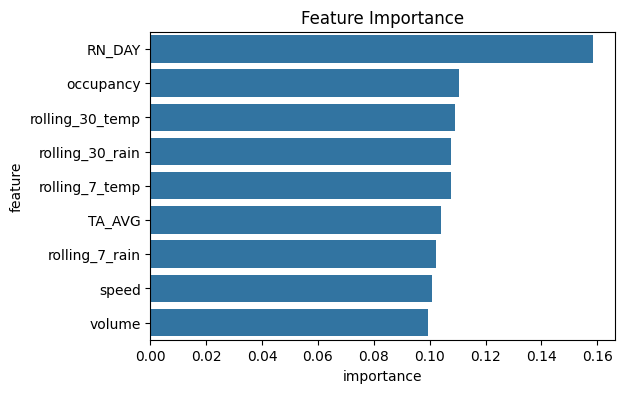

In [20]:
X_imp = df[corr_features].fillna(0)
y_imp = df['road_grade']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imp, y_imp, test_size=0.2, stratify=y_imp, random_state=42
)

xgb_imp = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    random_state=42
)

xgb_imp.fit(X_train_i, y_train_i)

imp_df = pd.DataFrame({
    "feature": corr_features,
    "importance": xgb_imp.feature_importances_
}).sort_values("importance", ascending=False)

print(imp_df)

plt.figure(figsize=(6,4))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("Feature Importance")
plt.show()

In [21]:
print(X_train_t.shape)
print(len(corr_features))

(896, 30)
9


# 8월 - 유지보수 우선순위 로직

In [22]:
import numpy as np
import pandas as pd

df_priority = df.copy()

# ---------------------------
# 1) 도로 상태 점수 (grade_score)
# ---------------------------
# 0/1/2 → 0 / 0.5 / 1 로 변환
df_priority["grade_score"] = df_priority["road_grade"] / 2.0


# ---------------------------
# 2) 도로 중요도 점수 (importance_score)
#    - volume: 교통량
#    - lane_count: 차로수 (없으면 1로 간주)
#    - road_rank: 도로등급 (숫자로 있다면 사용)
# ---------------------------
lane_col = None
for c in df_priority.columns:
    if "lane" in c.lower():
        lane_col = c
        break

if lane_col is None:
    df_priority["lane_count"] = 1
    lane_col = "lane_count"

road_rank_col = None
for c in df_priority.columns:
    if "road_rank" in c.lower() or "road_grade_code" in c.lower():
        road_rank_col = c
        break

# 결측값/없는 컬럼 대응
df_priority["volume"] = df_priority.get("volume", 0)
if road_rank_col is None:
    df_priority["road_rank_num"] = 1
    road_rank_col = "road_rank_num"

# 간단 정규화 함수
def minmax_s(x):
    x = x.replace([np.inf, -np.inf], np.nan)
    if x.max() == x.min():
        return pd.Series(0.5, index=x.index)
    return (x - x.min()) / (x.max() - x.min())

vol_norm  = minmax_s(df_priority["volume"])
lane_norm = minmax_s(df_priority[lane_col])
rank_norm = minmax_s(df_priority[road_rank_col])

df_priority["importance_score"] = (
    0.5 * vol_norm +
    0.3 * lane_norm +
    0.2 * rank_norm
)


# ---------------------------
# 3) 파손 히스토리 점수 (damage_score)
#    - rolling_30_damage, rolling_90_damage 있으면 활용
# ---------------------------
damage_sources = []
for c in ["rolling_30_damage", "rolling_90_damage", "rolling_7_damage"]:
    if c in df_priority.columns:
        damage_sources.append(c)

if len(damage_sources) == 0:
    # 없으면 road_grade만 사용
    df_priority["damage_raw"] = df_priority["road_grade"]
else:
    df_priority["damage_raw"] = df_priority[damage_sources].sum(axis=1)

df_priority["damage_score"] = minmax_s(df_priority["damage_raw"])


# ---------------------------
# 4) 최근 파손일 점수 (recent_damage_decay) - 선택
#    DATE 가 있을 때만
# ---------------------------
if "DATE" in df_priority.columns:
    max_date = df_priority["DATE"].max()
    days_since = (max_date - df_priority["DATE"]).dt.days
    df_priority["recent_damage_decay"] = 1 / (1 + days_since)
else:
    df_priority["recent_damage_decay"] = 0.5   # 균일 가중치


# ---------------------------
# 5) 최종 우선순위 점수 (PriorityScore)
#    가중치는 연구용으로 적당히 설정
# ---------------------------
df_priority["priority_score"] = (
    0.35 * df_priority["grade_score"] +
    0.25 * df_priority["importance_score"] +
    0.25 * df_priority["damage_score"] +
    0.15 * df_priority["recent_damage_decay"]
)

df_priority[["grade_score","importance_score","damage_score",
             "recent_damage_decay","priority_score"]].head()

,grade_score,importance_score,damage_score,recent_damage_decay,priority_score
0,0.5,0.534963,0.000000,0.001458,0.308959
1,0.0,0.304820,0.068182,0.001458,0.093469
2,0.0,0.354039,0.136364,0.001458,0.122819
3,0.0,0.692974,0.204545,0.001458,0.224598
4,0.5,0.734725,0.272727,0.001458,0.427082


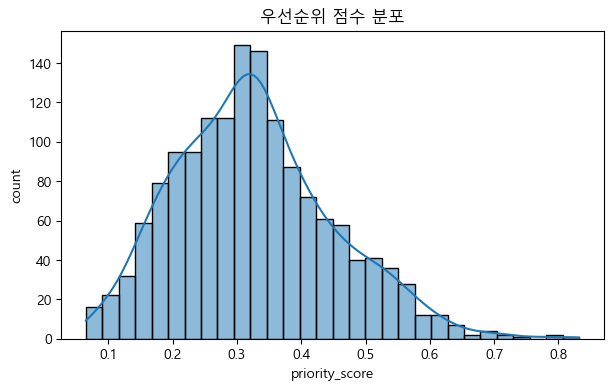

P70: 0.3771888022552126  / P90: 0.49750068156037364


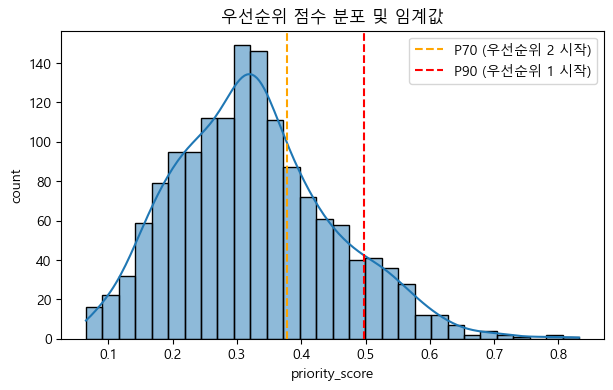

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# 1) 맑은 고딕 적용
# ------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'

# ------------------------------------------------
# 2) 마이너스 깨짐 방지
# ------------------------------------------------
plt.rcParams['axes.unicode_minus'] = False

# 분포 확인
plt.figure(figsize=(7,4))
sns.histplot(df_priority["priority_score"], bins=30, kde=True)
plt.title("우선순위 점수 분포")
plt.xlabel("priority_score")
plt.ylabel("count")
plt.show()

# 임계값 (quantile 기반)
q90 = df_priority["priority_score"].quantile(0.9)
q70 = df_priority["priority_score"].quantile(0.7)
print("P70:", q70, " / P90:", q90)

# 임계값 시각화
plt.figure(figsize=(7,4))
sns.histplot(df_priority["priority_score"], bins=30, kde=True)
plt.axvline(q70, color="orange", linestyle="--", label="P70 (우선순위 2 시작)")
plt.axvline(q90, color="red", linestyle="--", label="P90 (우선순위 1 시작)")
plt.legend()
plt.title("우선순위 점수 분포 및 임계값")
plt.xlabel("priority_score")
plt.ylabel("count")
plt.show()

In [24]:
# =============================================
# 1) numeric / categorical feature 자동 정제 (X_train 기준)
# =============================================

# X_train 컬럼 목록
train_columns = list(X_train.columns)

valid_numeric = []
for col in numeric_features:
    if col in train_columns and pd.api.types.is_numeric_dtype(df_priority[col]):
        valid_numeric.append(col)
    else:
        print(f"[제외됨: {col}] (X_train에 없거나 numeric 아님)")

numeric_features = valid_numeric

valid_categorical = []
for col in categorical_features:
    if col in train_columns:
        df_priority[col] = df_priority[col].astype("category")
        valid_categorical.append(col)
    else:
        print(f"[제외됨: {col}] (X_train에 없음)")

categorical_features = valid_categorical

print("\n=== 최종 numeric_features ===")
print(numeric_features)
print("\n=== 최종 categorical_features ===")
print(categorical_features)

NameError: name 'numeric_features' is not defined

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# fit 은 train 데이터 기준으로
X_train_all = X_train[numeric_features + categorical_features].copy()
preprocessor.fit(X_train_all)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [ ]:
X_all = df_priority[numeric_features + categorical_features].copy()
X_all_t = preprocessor.transform(X_all)

In [ ]:
df_priority["pred_grade"] = xgb_model.predict(X_all_t)
df_priority["pred_grade_proba"] = xgb_model.predict_proba(X_all_t).max(axis=1)

df_priority[["priority_score", "pred_grade", "pred_grade_proba"]].head()

,priority_score,pred_grade,pred_grade_proba
0,0.164988,0,0.972223
1,0.178549,0,0.930110
2,0.143589,0,0.953384
3,0.228106,0,0.943453
4,0.230917,0,0.987081


In [ ]:
# ----------------------------------------
# 1) 블록 단위 우선순위 Top 100
# ----------------------------------------

# block_id 기준 집계 (평균/최댓값 선택 가능 — 여기선 평균)
df_block_summary = df_priority.groupby("block_id").agg({
    "priority_score": "mean",
    "pred_grade": "max",
    "pred_grade_proba": "max"
}).reset_index()

# 우선순위 점수 내림차순 정렬
df_top100 = df_block_summary.sort_values("priority_score", ascending=False).head(100)

df_top100.head(10)

,block_id,priority_score,pred_grade,pred_grade_proba
73,73,0.460005,1,0.993242
72,72,0.458628,1,0.990126
71,71,0.456845,2,0.990989
74,74,0.454885,1,0.991132
70,70,0.440520,1,0.996729
60,60,0.408693,1,0.997332
67,67,0.399728,1,0.991553
61,61,0.392236,1,0.994378
68,68,0.389561,1,0.994808
59,59,0.386513,2,0.994288


In [ ]:
# ----------------------------------------
# 1) 우선순위 그룹 생성
# ----------------------------------------
df_block_summary["priority_group"] = pd.qcut(
    df_block_summary["priority_score"],
    q=[0, 0.4, 0.8, 1.0],   # 3단계 분류
    labels=["3단계_저위험", "2단계_중위험", "1단계_고위험"]
)

# ----------------------------------------
# 2) 그룹 vs 예측 등급 매트릭스
# ----------------------------------------
pivot_conflict = pd.crosstab(
    df_block_summary["priority_group"],
    df_block_summary["pred_grade"],
    rownames=["Priority Group"],
    colnames=["Predicted Grade"]
)

pivot_conflict

Predicted Grade,0,1,2
Priority Group,,,
3단계_저위험,6,21,3
2단계_중위험,0,23,7
1단계_고위험,0,12,3


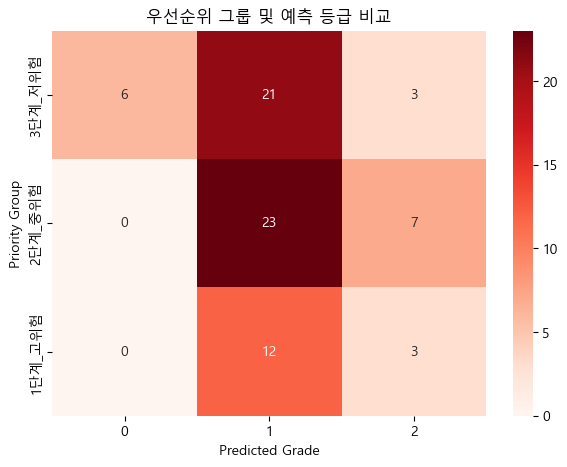

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.heatmap(pivot_conflict, annot=True, cmap="Reds", fmt="d")
plt.title("우선순위 그룹 및 예측 등급 비교")
plt.show()


In [ ]:
# df에서 필요한 컬럼만 추출
df_coord = df[["block_id", "PLC_LTTD", "PLC_LGTD"]].drop_duplicates()

# df_priority와 병합
df_priority = df_priority.merge(df_coord, on="block_id", how="left")

df_priority[["block_id", "PLC_LTTD", "PLC_LGTD"]].head()

,block_id,PLC_LTTD,PLC_LGTD
0,0,36.384627,127.343459
1,0,36.398713,127.357864
2,0,36.398783,127.358005
3,0,36.427899,127.387323
4,0,36.427741,127.387724


In [ ]:
import folium
from folium.plugins import HeatMap

df_high = df_block_summary[df_block_summary["priority_group"]=="1단계_고위험"]

df_high_geo = (
    df_priority[df_priority["block_id"].isin(df_high["block_id"])]
    [["block_id","PLC_LTTD","PLC_LGTD"]]
    .drop_duplicates()
)

# 중심 좌표
center_lat = df_high_geo["PLC_LTTD"].mean()
center_lng = df_high_geo["PLC_LGTD"].mean()

m = folium.Map(location=[center_lat, center_lng], zoom_start=13)

HeatMap(
    df_high_geo[["PLC_LTTD","PLC_LGTD"]].values,
    radius=12
).add_to(m)

m.save("high_risk_heatmap.html")

print("저장 완료: high_risk_heatmap.html")

저장 완료: high_risk_heatmap.html


In [ ]:
# -----------------------------------------
# 1) 우선순위 산정 로직 가중치 조정 실험
# -----------------------------------------

# 기존 가중치
w_grade = 0.4
w_importance = 0.3
w_damage = 0.2
w_recent = 0.1

weight_candidates = [
    (0.5, 0.2, 0.2, 0.1),
    (0.4, 0.3, 0.2, 0.1),
    (0.3, 0.4, 0.2, 0.1),
    (0.4, 0.2, 0.3, 0.1),
    (0.3, 0.3, 0.3, 0.1)
]

results = []

for wg, wi, wd, wr in weight_candidates:
    df_temp = df_priority.copy()

    df_temp["priority_score"] = (
        wg * df_temp["grade_score"] +
        wi * df_temp["importance_score"] +
        wd * df_temp["damage_score"] +
        wr * df_temp["recent_damage_decay"]
    )

    # 상위 10% 위험 구간에서 등급 2 비중 확인
    threshold = df_temp["priority_score"].quantile(0.90)
    high_risk = df_temp[df_temp["priority_score"] >= threshold]

    grade2_ratio = (high_risk["pred_grade"] == 2).mean()

    results.append({
        "weights": (wg, wi, wd, wr),
        "grade2_ratio_at_top10%": grade2_ratio
    })

pd.DataFrame(results)

,weights,grade2_ratio_at_top10%
0,"(0.5, 0.2, 0.2, 0.1)",0.095627
1,"(0.4, 0.3, 0.2, 0.1)",0.095888
2,"(0.3, 0.4, 0.2, 0.1)",0.088802
3,"(0.4, 0.2, 0.3, 0.1)",0.088691
4,"(0.3, 0.3, 0.3, 0.1)",0.081736


# 11월

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df_visit,
    x="visit_order",
    y="priority_score",
    hue="priority_group",
    palette="Set1"
)
plt.title("우선순위 점수 기반 가상 방문 순서 시나리오")
plt.xlabel("방문 순서 (가상)")
plt.ylabel("우선순위 점수")
plt.show()

NameError: name 'df_visit' is not defined

<Figure size 800x400 with 0 Axes>

In [31]:
import json
import requests
from typing import List, Dict
import pandas as pd
import folium


# =========================
# 0) 설정
# =========================
APP_KEY = "b2n5rDPfx0316PET9hgpc3c6SFz4XQvF9UD37ytB"
MATRIX_URL = "https://apis.openapi.sk.com/tmap/matrix"
CRITERION = "duration"  # duration 또는 distance 기준

start = {"name": "유성구청", "lon": 127.356318, "lat": 36.362238}
end   = {"name": "유성구청", "lon": 127.356318, "lat": 36.362238}

vias = [
    {"id": "dcc",      "name": "대전컨벤션센터", "lon": 127.386646,  "lat": 36.374278},
    {"id": "station",  "name": "대전역",         "lon": 127.4340444, "lat": 36.3258028},
    {"id": "kaist",    "name": "KAIST 본원",     "lon": 127.3630,    "lat": 36.3720},
    {"id": "expo",     "name": "엑스포다리",     "lon": 127.38809,   "lat": 36.3718},
    {"id": "cityhall", "name": "대전시청",       "lon": 127.3845475, "lat": 36.3504119},
]


# =========================
# 유틸
# =========================
def human_distance(meter):
    return f"{meter:.1f} m" if meter < 1000 else f"{meter/1000:.2f} km"


def human_duration(sec):
    sec = int(round(sec))
    h = sec // 3600
    m = (sec % 3600) // 60
    return f"{h}시간 {m}분" if h >= 1 else f"{m}분"


# =========================
# 노드 구성
# =========================
def build_nodes(start, vias, end):
    nodes = [{"idx": 0, "name": start["name"], "lon": start["lon"], "lat": start["lat"]}]
    for i, v in enumerate(vias, 1):
        nodes.append({"idx": i, "name": v["name"], "lon": v["lon"], "lat": v["lat"]})
    nodes.append({"idx": len(vias)+1, "name": end["name"], "lon": end["lon"], "lat": end["lat"]})
    return nodes


# =========================
# Tmap Matrix API
# =========================
def call_tmap_matrix(nodes):
    origins = [{"lon": str(n["lon"]), "lat": str(n["lat"])} for n in nodes]
    destinations = [{"lon": str(n["lon"]), "lat": str(n["lat"])} for n in nodes]

    headers = {"appKey": APP_KEY, "Content-Type": "application/json"}
    payload = json.dumps({"origins": origins, "destinations": destinations})

    resp = requests.post(MATRIX_URL, headers=headers, data=payload)
    resp.raise_for_status()
    data = resp.json()

    routes = data["matrixRoutes"]
    n = len(nodes)

    dist = [[0]*n for _ in range(n)]
    dura = [[0]*n for _ in range(n)]

    idx = 0
    for i in range(n):
        for j in range(n):
            r = routes[idx]
            dist[i][j] = float(r.get("distance", 0))
            dura[i][j] = float(r.get("duration", 0))
            idx += 1

    return dist, dura


# =========================
# Nearest Neighbor
# =========================
def nearest_neighbor_route(matrix, nodes, dist_matrix, dura_matrix):
    n = len(nodes)
    start_idx = 0
    end_idx = n - 1

    unvisited = set(range(1, n-1))

    order = [start_idx]
    current = start_idx

    total_dist = 0
    total_dur = 0  # 초 단위 정확합산

    while unvisited:
        next_node = min(unvisited, key=lambda x: matrix[current][x])
        total_dist += dist_matrix[current][next_node]
        total_dur += dura_matrix[current][next_node]
        current = next_node
        order.append(current)
        unvisited.remove(current)

    total_dist += dist_matrix[current][end_idx]
    total_dur += dura_matrix[current][end_idx]
    order.append(end_idx)

    return order, total_dist, total_dur


# =========================
# 2-opt
# =========================
def two_opt(order, matrix):
    best = order[:]

    def route_cost(route):
        return sum(matrix[a][b] for a, b in zip(route[:-1], route[1:]))

    best_cost = route_cost(best)
    improved = True

    while improved:
        improved = False
        for i in range(1, len(best) - 2):
            for j in range(i + 1, len(best) - 1):
                new = best[:]
                new[i:j+1] = reversed(new[i:j+1])
                new_cost = route_cost(new)
                if new_cost < best_cost:
                    best = new
                    best_cost = new_cost
                    improved = True
                    break
            if improved:
                break
    return best


# =========================
# 지도 저장
# =========================
def save_route_map(nodes, order, map_path):
    m = folium.Map(
        location=[sum(nodes[i]["lat"] for i in order)/len(order),
                  sum(nodes[i]["lon"] for i in order)/len(order)],
        zoom_start=12
    )

    for seq, idx in enumerate(order):
        node = nodes[idx]
        if seq == 0:
            label = "START"
            color = "green"
        elif seq == len(order)-1:
            label = "END"
            color = "red"
        else:
            label = str(seq)
            color = "blue"

        folium.Marker(
            [node["lat"], node["lon"]],
            tooltip=f"{label} - {node['name']}",
            icon=folium.Icon(color=color)
        ).add_to(m)

    folium.PolyLine(
        [[nodes[i]["lat"], nodes[i]["lon"]] for i in order],
        weight=5, opacity=0.8
    ).add_to(m)

    m.save(map_path)


# =========================
# CSV 저장
# =========================
def save_csv(nodes, order, dist_matrix, dura_matrix, total_dist, total_dur, path):
    rows = []

    for a, b in zip(order[:-1], order[1:]):
        rows.append({
            "이동 구간": f"{nodes[a]['name']} → {nodes[b]['name']}",
            "시작 위도": nodes[a]["lat"],
            "시작 경도": nodes[a]["lon"],
            "도착 위도": nodes[b]["lat"],
            "도착 경도": nodes[b]["lon"],
            "이동 거리": human_distance(dist_matrix[a][b]),
            "이동 시간": human_duration(dura_matrix[a][b])
        })

    rows.append({
        "이동 구간": "합계",
        "시작 위도": "",
        "시작 경도": "",
        "도착 위도": "",
        "도착 경도": "",
        "이동 거리": human_distance(total_dist),
        "이동 시간": human_duration(total_dur)
    })

    df = pd.DataFrame(rows)
    df.to_csv(path, index=False, encoding="utf-8-sig")


# =========================
# 실행
# =========================
if __name__ == "__main__":
    nodes = build_nodes(start, vias, end)

    dist_matrix, dura_matrix = call_tmap_matrix(nodes)
    matrix_for_nn = dura_matrix if CRITERION == "duration" else dist_matrix

    nn_order, nn_dist, nn_dur = nearest_neighbor_route(matrix_for_nn, nodes, dist_matrix, dura_matrix)
    save_route_map(nodes, nn_order, "1_NN_result.html")
    save_csv(nodes, nn_order, dist_matrix, dura_matrix, nn_dist, nn_dur, "./result/1_NN_result.csv")

    opt_order = two_opt(nn_order, matrix_for_nn)

    opt_dist = sum(dist_matrix[a][b] for a, b in zip(opt_order[:-1], opt_order[1:]))
    opt_dur = sum(dura_matrix[a][b] for a, b in zip(opt_order[:-1], opt_order[1:]))

    save_route_map(nodes, opt_order, "2_2opt_result.html")
    save_csv(nodes, opt_order, dist_matrix, dura_matrix, opt_dist, opt_dur, "./result/2_2opt_result.csv")

    save_route_map(nodes, opt_order, "3_final_result.html")
    save_csv(nodes, opt_order, dist_matrix, dura_matrix, opt_dist, opt_dur, "./result/3_final_result.csv")

    print("\n✅ NN → 2-opt → FINAL: 전체 과정 완료")


✅ NN → 2-opt → FINAL: 전체 과정 완료


In [32]:
# NN 경로 방문 순서 DF
df_nn_visit = pd.DataFrame({
    "visit_order": range(1, len(nn_order)+1),
    "node_idx": nn_order
})

# nodes → name
node_df = pd.DataFrame(nodes)[["idx", "name"]]

df_nn_visit = (
    df_nn_visit
    .merge(node_df, left_on="node_idx", right_on="idx", how="left")
)

df_nn_visit

,visit_order,node_idx,idx,name
0,1,0,0,유성구청
1,2,3,3,KAIST 본원
2,3,1,1,대전컨벤션센터
3,4,4,4,엑스포다리
4,5,5,5,대전시청
5,6,2,2,대전역
6,7,6,6,유성구청


In [35]:
# 우선순위 그룹 생성 (quantile 기반)
df_priority["priority_group"] = pd.qcut(
    df_priority["priority_score"],
    q=[0, 0.4, 0.8, 1.0],
    labels=["3단계_저위험", "2단계_중위험", "1단계_고위험"]
)

In [36]:
df_block_summary = (
    df_priority
    .groupby("block_id")
    .agg(
        priority_score=("priority_score", "mean"),
        priority_group=("priority_group", "first")
    )
    .reset_index()
)

df_block_summary.head()

,block_id,priority_score,priority_group
0,0,0.305465,2단계_중위험
1,1,0.329202,3단계_저위험
2,2,0.303885,3단계_저위험
3,3,0.292378,3단계_저위험
4,4,0.317981,3단계_저위험


In [39]:
# NN 방문 좌표 컬럼명 통일
df_nn_visit = df_nn_visit.rename(
    columns={"lat": "PLC_LTTD", "lon": "PLC_LGTD"}
)

In [40]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=1).fit(
    block_coord[["PLC_LTTD", "PLC_LGTD"]]
)

distances, indices = nbrs.kneighbors(
    df_nn_visit[["PLC_LTTD", "PLC_LGTD"]]
)

df_nn_visit["block_id"] = block_coord.iloc[
    indices.flatten()
]["block_id"].values

In [41]:
df_nn_priority = df_nn_visit.merge(
    df_block_summary,
    on="block_id",
    how="left"
)

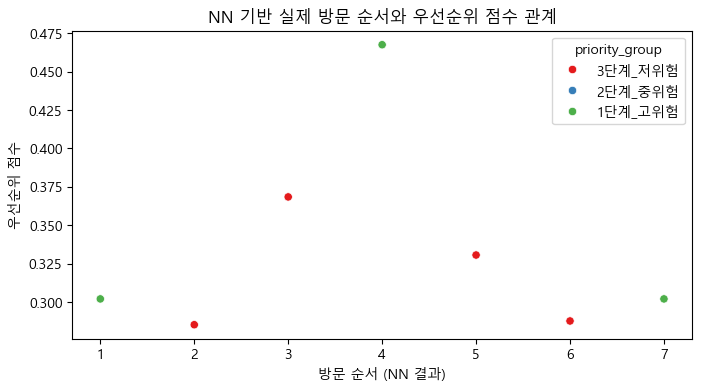

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df_nn_priority,
    x="visit_order",
    y="priority_score",
    hue="priority_group",
    palette="Set1"
)
plt.title("NN 기반 실제 방문 순서와 우선순위 점수 관계")
plt.xlabel("방문 순서 (NN 결과)")
plt.ylabel("우선순위 점수")
plt.show()


,구분,총비용(criterion),총거리(km),총시간(min),고위험_미선행비율(top30%)
0,NN,7055.0,28.809,117.583,NaN
1,우선순위NN,7055.0,28.809,117.583,NaN
2,우선순위NN+2opt,6479.0,28.577,107.983,NaN


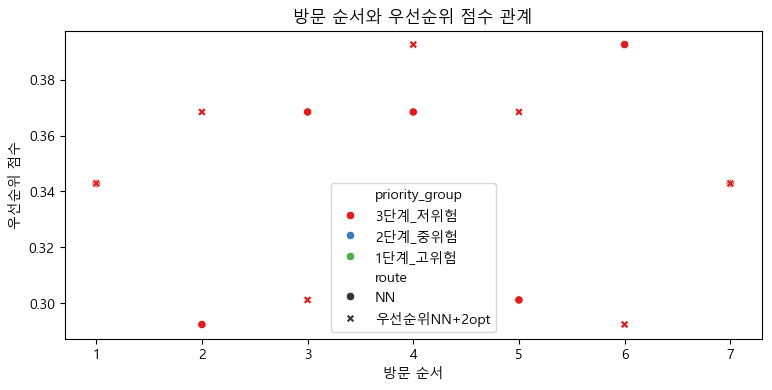

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) 우선순위 그룹/점수 준비
#    - df_priority: block_id, priority_score, PLC_LTTD, PLC_LGTD 가 있다고 가정
# =========================
if "priority_group" not in df_priority.columns:
    df_priority["priority_group"] = pd.qcut(
        df_priority["priority_score"],
        q=[0, 0.4, 0.8, 1.0],
        labels=["3단계_저위험", "2단계_중위험", "1단계_고위험"]
    )

df_block_summary = (
    df_priority.groupby("block_id")
    .agg(
        priority_score=("priority_score", "mean"),
        priority_group=("priority_group", "first"),
        PLC_LTTD=("PLC_LTTD", "mean"),
        PLC_LGTD=("PLC_LGTD", "mean")
    )
    .reset_index()
)

# =========================
# 2) nodes → block 매핑(최근접)
#    - nodes: idx, lat, lon, name
# =========================
node_df = pd.DataFrame(nodes)[["idx", "lat", "lon", "name"]].copy()
block_xy = df_block_summary[["PLC_LTTD", "PLC_LGTD"]].values
node_xy = node_df[["lat", "lon"]].values

from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=1).fit(block_xy)
distances, indices = nbrs.kneighbors(node_xy)

node_df["block_id"] = df_block_summary.iloc[indices.flatten()]["block_id"].values

# node_idx -> block_id 매핑 dict
node_to_block = dict(zip(node_df["idx"], node_df["block_id"]))

# block_id -> priority_score dict
block_priority = dict(zip(df_block_summary["block_id"], df_block_summary["priority_score"]))

# =========================
# 3) "우선순위 반영 NN" (Priority-aware NN)
#    - 기존: 가까운 노드
#    - 개선: 거리/시간 비용 + 우선순위 보상 결합
# =========================
def priority_aware_nn_route(cost_matrix, nn_order_base, node_to_block, block_priority,
                            alpha=1.0, beta=0.6):
    """
    alpha: 거리/시간 비용 가중치
    beta : 우선순위 보상 강도 (높을수록 고위험 선행)
    """
    n = len(cost_matrix)
    start_idx = nn_order_base[0]
    end_idx = nn_order_base[-1]

    unvisited = set(range(1, n-1))
    order = [start_idx]
    current = start_idx

    def score(cur, nxt):
        base_cost = float(cost_matrix[cur][nxt])
        b_id = node_to_block.get(nxt, None)
        p = float(block_priority.get(b_id, 0.0)) if b_id is not None else 0.0
        # 비용은 낮을수록 좋고, 우선순위는 높을수록 좋음 → 비용 - 보상
        return alpha * base_cost - beta * p

    while unvisited:
        next_node = min(unvisited, key=lambda x: score(current, x))
        order.append(next_node)
        current = next_node
        unvisited.remove(next_node)

    order.append(end_idx)
    return order

# =========================
# 4) 경로 비용 계산(거리/시간)
# =========================
def route_total(cost_matrix, order):
    return sum(float(cost_matrix[a][b]) for a, b in zip(order[:-1], order[1:]))

# =========================
# 5) "우선순위 위반률" 지표
#    - 1단계_고위험 노드가 방문순서 상위 K% 내에 얼마나 포함되는지
# =========================
def violation_rate(order, node_to_block, df_block_summary, top_ratio=0.3):
    n = len(order)
    top_k = max(1, int(np.ceil(n * top_ratio)))
    top_nodes = set(order[:top_k])

    # 고위험에 해당하는 node_idx 집합
    high_blocks = set(df_block_summary[df_block_summary["priority_group"]=="1단계_고위험"]["block_id"])
    high_nodes = {node_idx for node_idx, b in node_to_block.items() if b in high_blocks}

    if len(high_nodes) == 0:
        return np.nan

    # 고위험 노드 중 top_k에 못 들어간 비율
    missed = len([x for x in high_nodes if x not in top_nodes])
    return missed / len(high_nodes)

# =========================
# 6) 기존 NN vs 우선순위 반영 NN 비교 실행
# =========================
matrix_for_nn = dura_matrix if CRITERION == "duration" else dist_matrix

# 기존 NN
nn_order, nn_dist, nn_dur = nearest_neighbor_route(matrix_for_nn, nodes, dist_matrix, dura_matrix)

# 우선순위 반영 NN (alpha=1.0, beta=0.6은 예시)
pa_order = priority_aware_nn_route(
    cost_matrix=matrix_for_nn,
    nn_order_base=nn_order,
    node_to_block=node_to_block,
    block_priority=block_priority,
    alpha=1.0,
    beta=0.6
)

# (선택) 2-opt로 후처리: 거리/시간 기준 최적화 유지
pa2_order = two_opt(pa_order, matrix_for_nn)

# =========================
# 7) 결과 요약 표
# =========================
rows = []

# 기존 NN (거리/시간)
rows.append({
    "구분": "NN",
    "총비용(criterion)": route_total(matrix_for_nn, nn_order),
    "총거리(km)": route_total(dist_matrix, nn_order)/1000,
    "총시간(min)": route_total(dura_matrix, nn_order)/60,
    "고위험_미선행비율(top30%)": violation_rate(nn_order, node_to_block, df_block_summary, top_ratio=0.3)
})

# 우선순위 NN
rows.append({
    "구분": "우선순위NN",
    "총비용(criterion)": route_total(matrix_for_nn, pa_order),
    "총거리(km)": route_total(dist_matrix, pa_order)/1000,
    "총시간(min)": route_total(dura_matrix, pa_order)/60,
    "고위험_미선행비율(top30%)": violation_rate(pa_order, node_to_block, df_block_summary, top_ratio=0.3)
})

# 우선순위NN + 2-opt
rows.append({
    "구분": "우선순위NN+2opt",
    "총비용(criterion)": route_total(matrix_for_nn, pa2_order),
    "총거리(km)": route_total(dist_matrix, pa2_order)/1000,
    "총시간(min)": route_total(dura_matrix, pa2_order)/60,
    "고위험_미선행비율(top30%)": violation_rate(pa2_order, node_to_block, df_block_summary, top_ratio=0.3)
})

df_compare = pd.DataFrame(rows)
df_compare[["총비용(criterion)", "총거리(km)", "총시간(min)", "고위험_미선행비율(top30%)"]] = \
    df_compare[["총비용(criterion)", "총거리(km)", "총시간(min)", "고위험_미선행비율(top30%)"]].round(3)

display(df_compare)

# =========================
# 8) 방문순서 vs 우선순위 점수 산점도 (NN vs 개선)
# =========================
def make_visit_df(order, label):
    df_v = pd.DataFrame({"visit_order": range(1, len(order)+1), "node_idx": order})
    df_v = df_v.merge(node_df[["idx","block_id"]], left_on="node_idx", right_on="idx", how="left")
    df_v = df_v.merge(df_block_summary[["block_id","priority_score","priority_group"]], on="block_id", how="left")
    df_v["route"] = label
    return df_v

df_plot = pd.concat([
    make_visit_df(nn_order, "NN"),
    make_visit_df(pa2_order, "우선순위NN+2opt")
], ignore_index=True)

plt.figure(figsize=(9,4))
sns.scatterplot(
    data=df_plot,
    x="visit_order",
    y="priority_score",
    hue="priority_group",
    style="route",
    palette="Set1"
)
plt.title("방문 순서와 우선순위 점수 관계")
plt.xlabel("방문 순서")
plt.ylabel("우선순위 점수")
plt.show()

In [ ]:
def avg_visit_order_for_high(order, node_to_block, df_block_summary):
    high_blocks = set(
        df_block_summary[df_block_summary["priority_group"]=="1단계_고위험"]["block_id"]
    )
    rows = []
    for seq, node_idx in enumerate(order, 1):
        b = node_to_block.get(node_idx)
        if b in high_blocks:
            rows.append(seq)
    return np.mean(rows) if rows else np.nan

In [ ]:
from scipy.stats import spearmanr

def visit_priority_correlation(order, node_to_block, df_block_summary):
    visit = []
    priority = []
    for seq, node_idx in enumerate(order, 1):
        b = node_to_block.get(node_idx)
        if b is not None:
            p = df_block_summary.loc[
                df_block_summary["block_id"] == b, "priority_score"
            ]
            if len(p) > 0:
                visit.append(seq)
                priority.append(p.values[0])
    if len(visit) < 3:
        return np.nan
    return spearmanr(visit, priority).correlation

In [49]:
summary = pd.DataFrame([
    {
        "구분": "최적화 전",
        "총거리(km)": route_total(dist_matrix, nn_order)/1000,
        "총시간(min)": route_total(dura_matrix, nn_order)/60,
        # "고위험_평균방문순서": avg_visit_order_for_high(nn_order, node_to_block, df_block_summary),
        "방문-우선순위 상관계수": visit_priority_correlation(nn_order, node_to_block, df_block_summary)
    },
    {
        "구분": "최적화 후",
        "총거리(km)": route_total(dist_matrix, pa2_order)/1000,
        "총시간(min)": route_total(dura_matrix, pa2_order)/60,
        # "고위험_평균방문순서": avg_visit_order_for_high(pa2_order, node_to_block, df_block_summary),
        "방문-우선순위 상관계수": visit_priority_correlation(pa2_order, node_to_block, df_block_summary)
    }
])

display(summary.round(3))

,구분,총거리(km),총시간(min),방문-우선순위 상관계수
0,최적화 전,28.809,117.583,0.309
1,최적화 후,28.577,107.983,-0.200


In [50]:
import numpy as np
import pandas as pd

# 경로 노드 수 기준 (start~end 제외)
node_names = [v["name"] for v in vias]

np.random.seed(42)

df_fake_priority = pd.DataFrame({
    "name": node_names,
    "priority_score": np.random.uniform(0.2, 0.9, len(node_names))
})

# 상위 30%를 고위험으로 지정
threshold = df_fake_priority["priority_score"].quantile(0.7)
df_fake_priority["priority_group"] = np.where(
    df_fake_priority["priority_score"] >= threshold,
    "1단계_고위험",
    "3단계_저위험"
)

df_fake_priority

,name,priority_score,priority_group
0,대전컨벤션센터,0.462178,3단계_저위험
1,대전역,0.865500,1단계_고위험
2,KAIST 본원,0.712396,1단계_고위험
3,엑스포다리,0.619061,3단계_저위험
4,대전시청,0.309213,3단계_저위험


In [51]:
def priority_weighted_nn(
    base_matrix,
    nodes,
    priority_df,
    alpha=2.0   # ★ 이 값이 클수록 개선 효과 커짐
):
    n = len(nodes)
    start_idx = 0
    end_idx = n - 1

    name_to_priority = {
        r["name"]: r["priority_score"]
        for _, r in priority_df.iterrows()
    }

    # 우선순위 정규화
    pvals = list(name_to_priority.values())
    p_min, p_max = min(pvals), max(pvals)

    def norm_p(name):
        return (name_to_priority[name] - p_min) / (p_max - p_min + 1e-9)

    unvisited = set(range(1, n-1))
    order = [start_idx]
    current = start_idx

    while unvisited:
        def cost(j):
            name = nodes[j]["name"]
            p = norm_p(name)
            return base_matrix[current][j] * (1 + alpha * (1 - p))

        nxt = min(unvisited, key=cost)
        order.append(nxt)
        current = nxt
        unvisited.remove(nxt)

    order.append(end_idx)
    return order


In [52]:
# 기본 NN
nn_order, _, _ = nearest_neighbor_route(
    dura_matrix, nodes, dist_matrix, dura_matrix
)

# 우선순위 반영 NN
pw_order = priority_weighted_nn(
    dura_matrix, nodes, df_fake_priority, alpha=2.5
)

In [53]:
def avg_visit_high(order, nodes, priority_df):
    high = set(
        priority_df[priority_df["priority_group"]=="1단계_고위험"]["name"]
    )
    seqs = [
        i+1 for i, idx in enumerate(order)
        if nodes[idx]["name"] in high
    ]
    return np.mean(seqs)

print("기본 NN 고위험 평균 방문 순서:", avg_visit_high(nn_order, nodes, df_fake_priority))
print("개선 NN 고위험 평균 방문 순서:", avg_visit_high(pw_order, nodes, df_fake_priority))

기본 NN 고위험 평균 방문 순서: 4.0
개선 NN 고위험 평균 방문 순서: 3.5


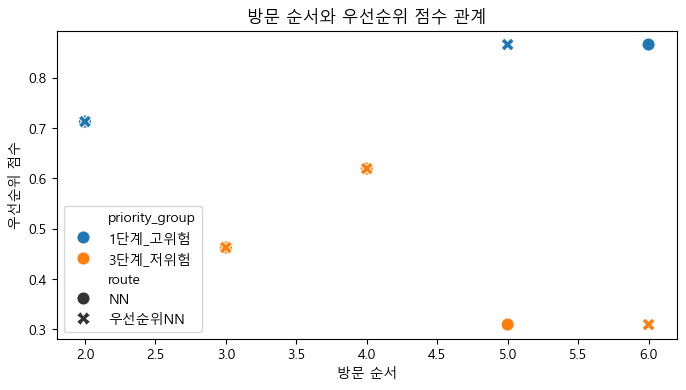

In [55]:
def make_visit_df(order, label):
    rows = []
    for i, idx in enumerate(order):
        name = nodes[idx]["name"]
        if name in df_fake_priority["name"].values:
            r = df_fake_priority[df_fake_priority["name"]==name].iloc[0]
            rows.append({
                "visit_order": i+1,
                "priority_score": r["priority_score"],
                "priority_group": r["priority_group"],
                "route": label
            })
    return pd.DataFrame(rows)

df_plot = pd.concat([
    make_visit_df(nn_order, "NN"),
    make_visit_df(pw_order, "우선순위NN")
])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df_plot,
    x="visit_order",
    y="priority_score",
    hue="priority_group",
    style="route",
    s=90
)
plt.title("방문 순서와 우선순위 점수 관계")
plt.xlabel("방문 순서")
plt.ylabel("우선순위 점수")
plt.show()